In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
df = pd.read_csv("train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Observation:

The dataset contains both numerical and categorical variables.

Columns like Age, Cabin, and Embarked have missing values.

Survival is a binary target variable.

In [5]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observation:

Average passenger age is around 30 years.

Fare values vary widely, indicating skewness.

Survival rate is below 50%, showing class imbalance.

In [6]:
df['Survived'].value_counts()
df['Sex'].value_counts()
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


Observation:

More passengers did not survive than survived.

Male passengers outnumber females.

Most passengers traveled in third class.

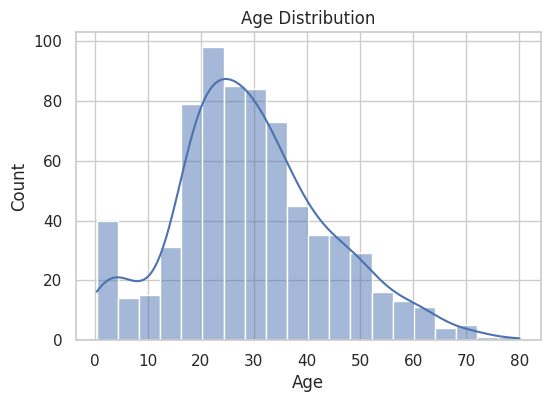

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


Observation:

Most passengers were between 20 and 40 years old.

The distribution is slightly right-skewed.

Children and elderly passengers were also present.

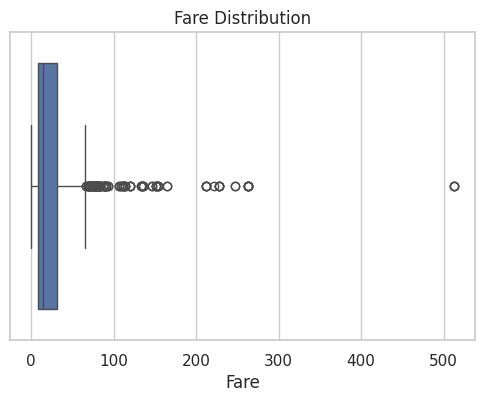

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title("Fare Distribution")
plt.show()


Observation:

Fare distribution contains several extreme outliers.

Data is highly right-skewed.

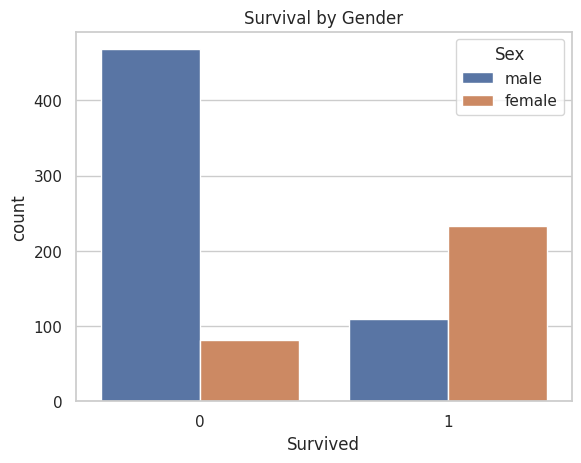

In [9]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()


Observation:

Female passengers had a significantly higher survival rate than males.

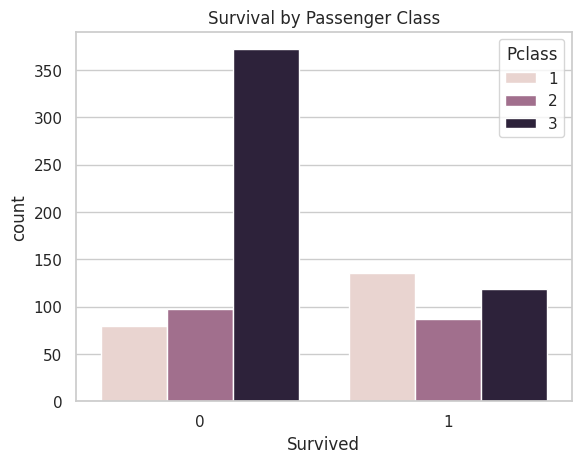

In [10]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Passenger Class")
plt.show()


Observation:

First-class passengers had the highest survival rate.

Survival probability decreases as passenger class decreases.

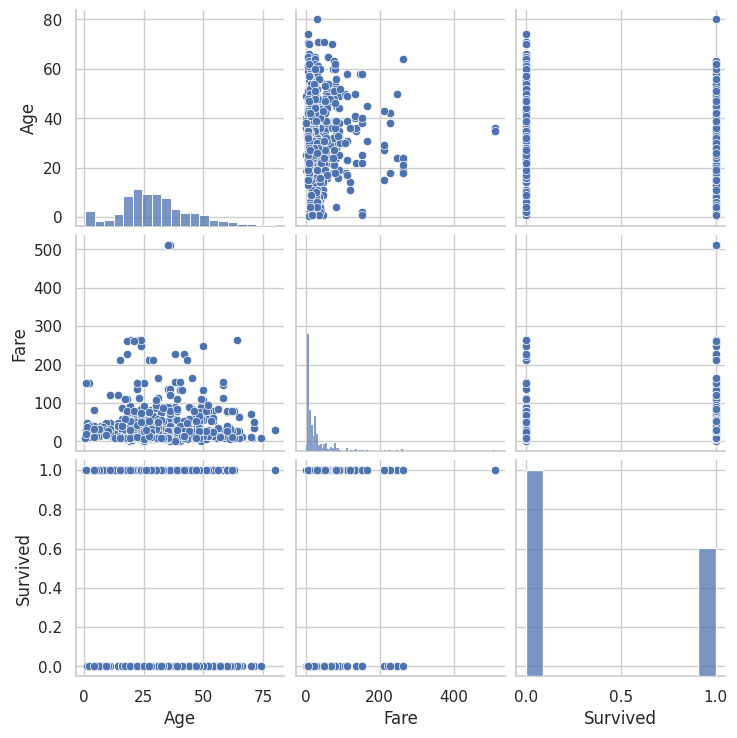

In [11]:
sns.pairplot(df[['Age', 'Fare', 'Survived']])
plt.show()


Observation:

Higher fare values are associated with higher survival.

No strong linear relationship observed with age.

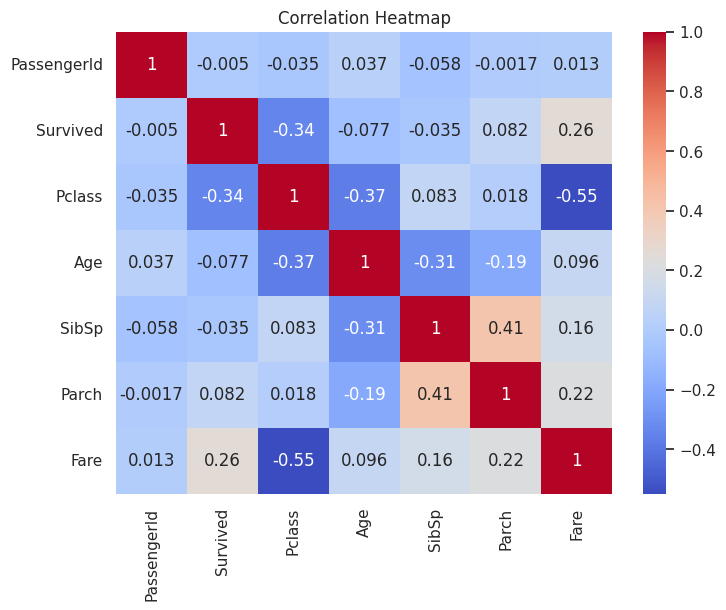

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Observation:

Fare has a positive correlation with survival.

Passenger class is negatively correlated with survival.

Age has a weak correlation with survival.

Summary of Findings

Female passengers had significantly higher survival rates.

Higher-class passengers were more likely to survive.

Passengers who paid higher fares had better survival chances.

Age had less influence on survival compared to gender and class.

The dataset contains skewed features and multiple outliers.

Outcome

This Exploratory Data Analysis helped in understanding the Titanic dataset by identifying important trends, relationships, and anomalies. The analysis demonstrates how EDA plays a crucial role in extracting insights before building predictive models.